# 4. Image Convolution

## Table of Contents
1. [Libraries](#libraries)
2. [Simple Example](#simple)
3. [PyTorch Convolution](#pytorch)

## Importing Libraries <a class="anchor" id="libraries" ></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

## Simple Convolution <a class="anchor" id="simple" ></a>

### Definition

- __I__: Image to convolve.
- __H__: filter matrix to convolve the image with.
- __J__: Result of the convolution.

The following graphics shows exemplary the mathematical operations of the convolution. The filter matrix __H__ is shifted over the input image __I__. The values 'under' the filter matrix are multiplicated with the corresponding values in __H__, summed up and writen to the result __J__. The target position is usually the position under the center of __H__.

<img src="data/convolution.png" width="70%">

In order to implement the convolution with a block filter, we need two methods. The first one will create the block filter matrix __H__ depending on the filter width/height __n__. 

A block filter holds the value $\dfrac{1}{n\cdot n}$ at each position:

In [2]:
def block_filter(n):
    H = np.ones((n, n)) / (n * n) # each element in H has the value 1/(n*n)
    return H

We will test the method by creating a filter with ``n = 5``:

In [3]:
H = block_filter(5)
print(H)

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


Next, we define the actual convolution operation. To prevent invalid indices at the border of the image, we introduce the padding __p__.

In [4]:
def apply_filter(I, H):
    h, w = I.shape                         # image dimensions (height, width)
    n = H.shape[0]                         # filter size
    p = n // 2                             # padding size
    J = np.zeros_like(I)                   # output image, initialized with zeros
    
    for x in range(p, h-p):
        for y in range(p, w-p):
            J[x, y] = np.sum(I[x-p:x+n-p, y-p:y+n-p] * H)
    return J

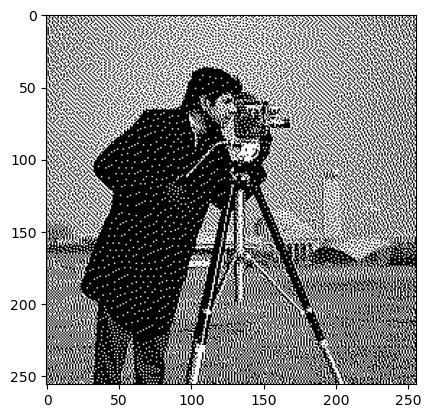

In [5]:
image = Image.open('data/image.jpg')
image = image.convert('1') # convert image to black and white

image = np.array(image)

# image = np.zeros((200, 200), dtype=np.float)
# for x in range(200):
#     for y in range(200):
#         d = ((x-100)**2+(y-100)**2)**0.5
#         image[x, y] = d % 8 < 4

plt.imshow(image, cmap='gray',vmin=0.0, vmax=1.0)
plt.show()

In [6]:
image = image.astype(float)

Next we test our implementation and apply a block filter with size 7

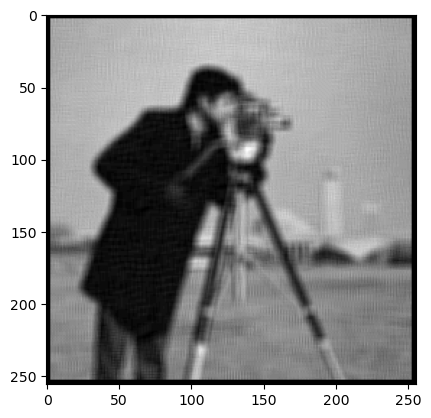

In [7]:
n = 7
H = block_filter(n)
J = apply_filter(image, H)

plt.imshow(J, cmap='gray')
plt.show()

## Ejercicio 1: Detectores de Línea (Prewitt, Sobel y Laplaciano)


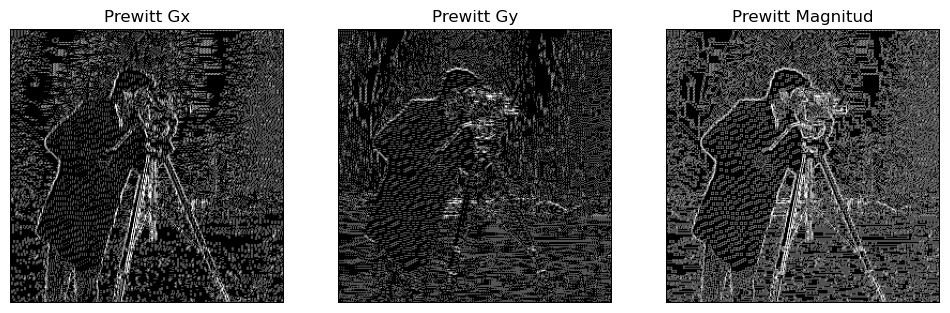

In [8]:
# --- Detector Prewitt ---
H_prewitt_x = np.array([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]])

H_prewitt_y = np.array([[-1, -1, -1],
                        [ 0,  0,  0],
                        [ 1,  1,  1]])

prewitt_x = apply_filter(image, H_prewitt_x)
prewitt_y = apply_filter(image, H_prewitt_y)
prewitt_mag = np.sqrt(prewitt_x**2 + prewitt_y**2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.abs(prewitt_x), cmap='gray')
axes[0].set_title('Prewitt Gx')
axes[1].imshow(np.abs(prewitt_y), cmap='gray')
axes[1].set_title('Prewitt Gy')
axes[2].imshow(prewitt_mag, cmap='gray')
axes[2].set_title('Prewitt Magnitud')
for ax in axes:
    ax.axis('off')
plt.show()

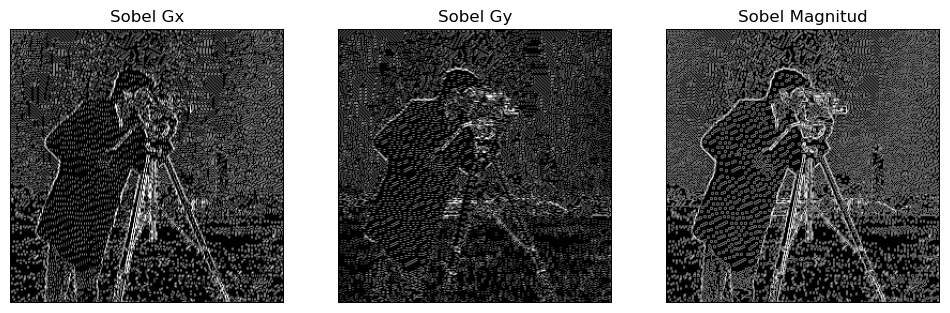

In [9]:
# --- Detector Sobel ---
H_sobel_x = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]])

H_sobel_y = np.array([[-1, -2, -1],
                      [ 0,  0,  0],
                      [ 1,  2,  1]])

sobel_x = apply_filter(image, H_sobel_x)
sobel_y = apply_filter(image, H_sobel_y)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.abs(sobel_x), cmap='gray')
axes[0].set_title('Sobel Gx')
axes[1].imshow(np.abs(sobel_y), cmap='gray')
axes[1].set_title('Sobel Gy')
axes[2].imshow(sobel_mag, cmap='gray')
axes[2].set_title('Sobel Magnitud')
for ax in axes:
    ax.axis('off')
plt.show()

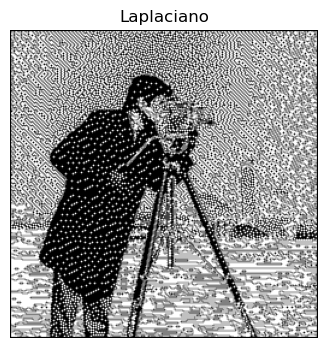

In [10]:
# --- Detector Laplaciano ---
H_laplacian = np.array([[ 0,  1,  0],
                        [ 1, -4,  1],
                        [ 0,  1,  0]])

laplacian_img = apply_filter(image, H_laplacian)

plt.figure(figsize=(4, 4))
plt.imshow(np.abs(laplacian_img), cmap='gray')
plt.title('Laplaciano')
plt.axis('off')
plt.show()

### Complejidad algorítmica: ¿Cuál es más eficiente?

- **El más eficiente en tiempo total es el Laplaciano:** Solo requiere **una convolución** sobre la imagen para obtener los bordes. En cambio, Prewitt y Sobel necesitan **dos convoluciones** (una horizontal $G_x$ y otra vertical $G_y$) más el cálculo de la magnitud vectorial ($\\sqrt{G_x^2 + G_y^2}$).
- **Entre Prewitt y Sobel, Prewitt es más eficiente aritméticamente:** Sus coeficientes son únicamente $1$ y $-1$, por lo que solo realiza sumas y restas sin multiplicaciones, mientras que Sobel multiplica por $2$. Sin embargo, Sobel ofrece bordes más limpios porque reduce mejor el ruido.

## PyTorch Convolution <a class="anchor" id="pytorch" ></a>

In [11]:
from PIL import Image

img = Image.open('data/image.jpg')
img.thumbnail((256,256), Image.LANCZOS) # Resize to half to reduce the size of this notebook.

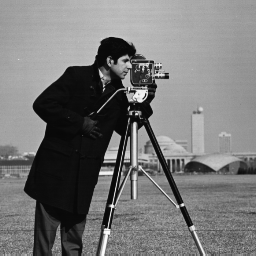

In [12]:
img

In [13]:
import torch, torchvision
from torchvision import transforms
from torch import nn

In [14]:
to_tensor = transforms.Compose([
   transforms.Grayscale(),  # Convert image to grayscale.
   transforms.ToTensor()    # Converts a PIL Image in the range [0, 255] to a torch.FloatTensor in the range [0.0, 1.0].
])

to_pil = transforms.Compose([
    transforms.ToPILImage()
])

In [15]:
input = to_tensor(img)
input.shape


torch.Size([1, 256, 256])

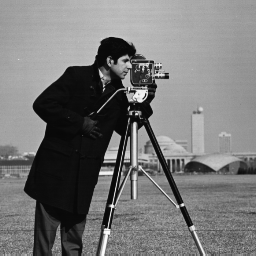

In [16]:
to_pil(input)

2D convolution over an input image:

+ `in_channels = 1`: an input is a grayscale image
+ `out_channels = 1`: an output is a grayscale image
+ `kernel_size = (3, 3)`: the kernel (filter) size is 3 x 3
+ `stride = 1`: the stride for the cross-correlation is 1
+ `padding = 1`: zero-paddings on both sides for 1 point for each dimension
+ `bias = False`: no bias parameter (for simplicity)

In [17]:
conv = nn.Conv2d(1, 1, (3, 3), stride=1, padding=1, bias=False)

In [18]:
# The code below does not work because the convolution layer requires the dimension for batch.
conv(input)

tensor([[[-0.2452, -0.2292, -0.2336,  ..., -0.2216, -0.2233, -0.1422],
         [-0.1234, -0.1485, -0.1459,  ..., -0.1501, -0.1481, -0.0194],
         [-0.1286, -0.1485, -0.1490,  ..., -0.1394, -0.1393, -0.0141],
         ...,
         [-0.0972, -0.1187, -0.0614,  ..., -0.1552, -0.1216, -0.0127],
         [-0.1106, -0.1119, -0.1378,  ..., -0.1269, -0.1023, -0.0149],
         [-0.1248, -0.2485, -0.3015,  ..., -0.2402, -0.2312, -0.0605]]],
       grad_fn=<SqueezeBackward1>)

We need to insert a dimension for a batch at dim=0.

In [19]:
input = input.unsqueeze(0)
input.shape

torch.Size([1, 1, 256, 256])

In [20]:
output = conv(input)
output.shape

torch.Size([1, 1, 256, 256])

Setting `padding=1` in the convolution layer, we obtain an image of the same size.

In [21]:
output.shape

torch.Size([1, 1, 256, 256])

We need to remove the first dimension before converting to a PIL object.

In [22]:
output.data.squeeze(dim=0).shape

torch.Size([1, 256, 256])

Display the output from the convolution layer by converting `output` to a PIL object.

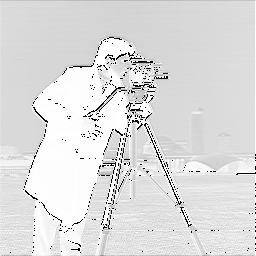

In [23]:
to_pil(output.data.squeeze(dim=0))

Clip every value in the output tensor within the range of [0, 1].

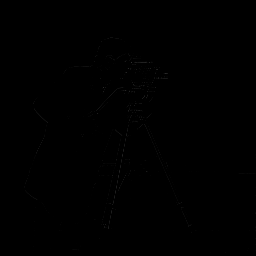

In [24]:
to_pil(torch.clamp(output, 0, 1).data.squeeze(dim=0))

In [25]:
def display(img1, img2):
    im1 = to_pil(torch.clamp(img1, 0, 1).data.squeeze(dim=0))
    im2 = to_pil(torch.clamp(img2, 0, 1).data.squeeze(dim=0))
    dst = Image.new('RGB', (im1.width + im2.width, im1.height))
    dst.paste(im1, (0, 0))
    dst.paste(im2, (im1.width, 0))
    return dst

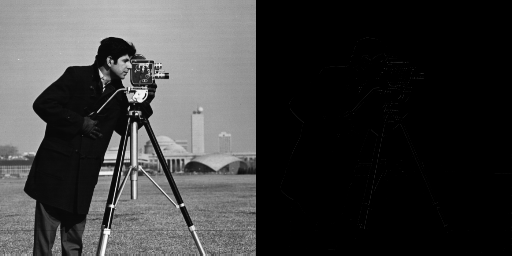

In [26]:
display(input, output)

### Identity

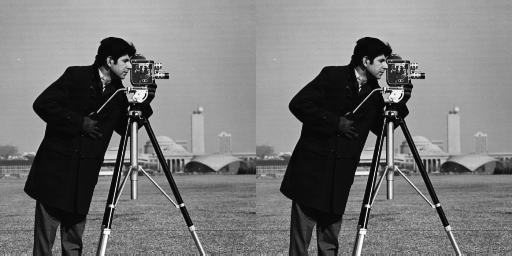

In [27]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 1, 0.],
    [0., 0., 0.],
]]])

output = conv(input)
display(input, output)

### Brighten

tensor([[[[0.0000, 0.0000, 0.0000],
          [0.0000, 1.5000, 0.0000],
          [0.0000, 0.0000, 0.0000]]]])


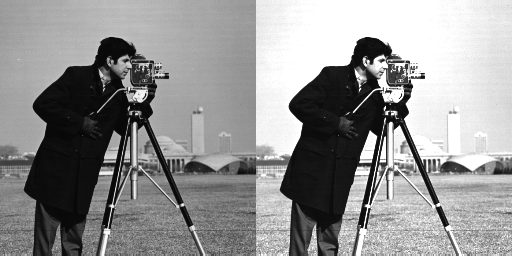

In [28]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 1.5, 0.],
    [0., 0., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Darken

tensor([[[[0.0000, 0.0000, 0.0000],
          [0.0000, 0.5000, 0.0000],
          [0.0000, 0.0000, 0.0000]]]])


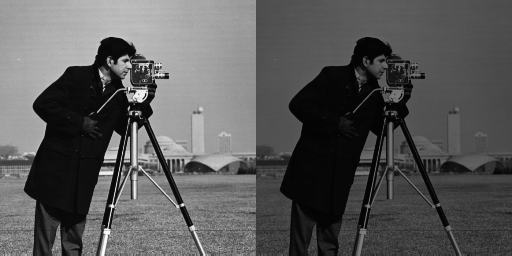

In [29]:
conv.weight.data = torch.tensor([[[
    [0., 0., 0.],
    [0., 0.5, 0.],
    [0., 0., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Box blur

tensor([[[[0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111],
          [0.1111, 0.1111, 0.1111]]]])


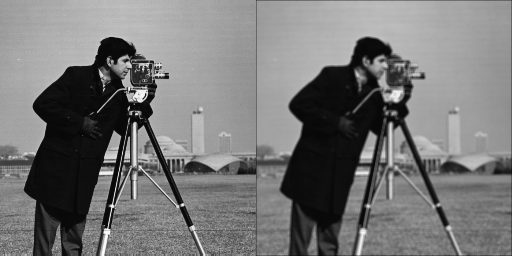

In [30]:
conv.weight.data = torch.ones((1, 1, 3,3), dtype=torch.float) / 9.
print(conv.weight.data)
output = conv(input)
display(input, output)

### Gaussian blur

tensor([[[[0.0625, 0.1250, 0.0625],
          [0.1250, 0.2500, 0.1250],
          [0.0625, 0.1250, 0.0625]]]])


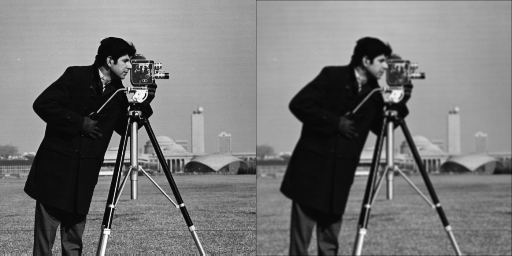

In [31]:
conv.weight.data = torch.tensor([[[
    [1., 2., 1.],
    [2., 4., 2.],
    [1., 2., 1.],
]]])/16.
print(conv.weight.data)
output = conv(input)
display(input, output)

### Sharpen

tensor([[[[ 0., -1.,  0.],
          [-1.,  5., -1.],
          [ 0., -1.,  0.]]]])


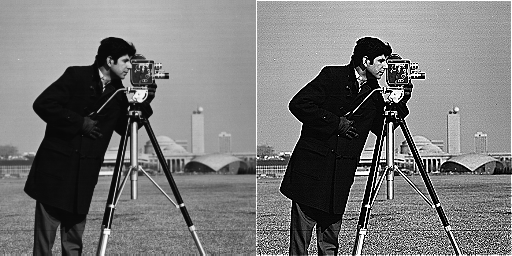

In [32]:
conv.weight.data = torch.tensor([[[
    [0., -1., 0.],
    [-1., 5., -1.],
    [0., -1., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

tensor([[[[ 0., -2.,  0.],
          [-2., 10., -2.],
          [ 0., -2.,  0.]]]])


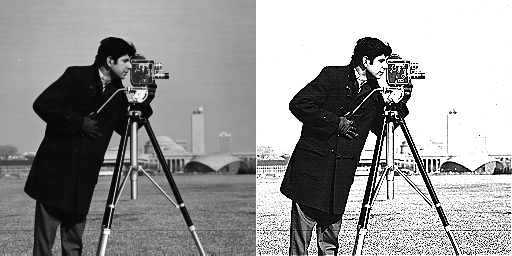

In [33]:
conv.weight.data = torch.tensor([[[
    [0., -2., 0.],
    [-2., 10., -2.],
    [0., -2., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

### Edge detection

tensor([[[[ 0.,  1.,  0.],
          [ 1., -4.,  1.],
          [ 0.,  1.,  0.]]]])


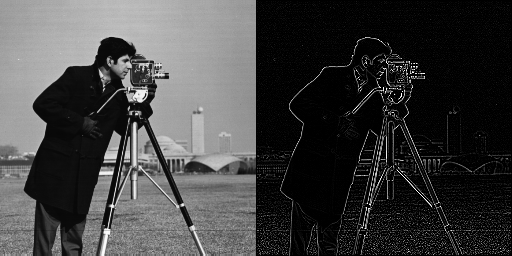

In [34]:
conv.weight.data = torch.tensor([[[
    [0., 1., 0.],
    [1., -4., 1.],
    [0., 1., 0.],
]]])
print(conv.weight.data)
output = conv(input)
display(input, output)

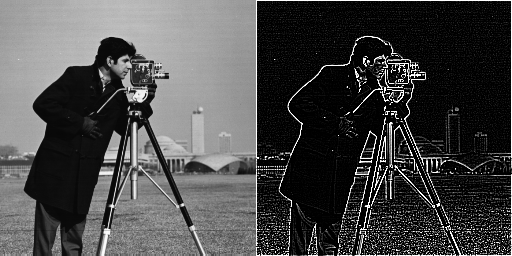

In [35]:
conv.weight.data = torch.tensor([[[
    [-1., -1., -1.],
    [-1., 8., -1.],
    [-1., -1., -1.],
]]])
output = conv(input)
display(input, output)

In [36]:
# TODO: Challenge, hard image with hard transformations

## Ejercicio 2: Algoritmo de Realce


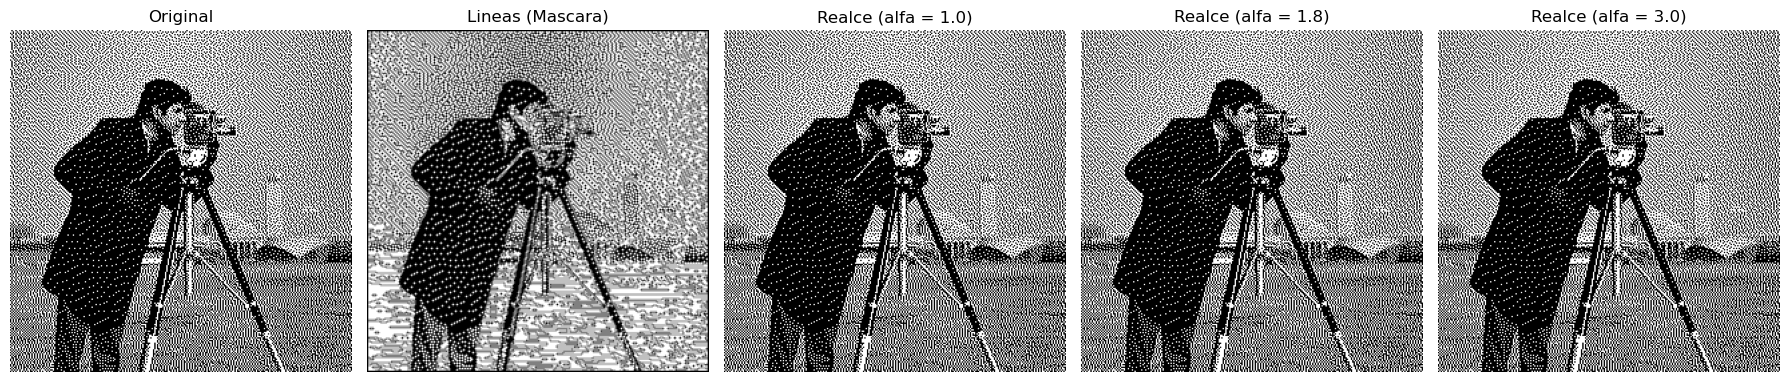

In [ ]:
# --- Ejercicio 2: ---

H_laplacian = np.array([[ 0,  1,  0],
                        [ 1, -4,  1],
                        [ 0,  1,  0]])

mask = apply_filter(image, H_laplacian)

alphas = [1.0, 1.8, 3.0]
realzadas = [np.clip(image - a * mask, 0.0, 1.0) for a in alphas]

# Visualizacion comparativa
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(np.abs(mask), cmap="gray")
axes[1].set_title("Lineas (Mascara)")

axes[2].imshow(realzadas[0], cmap="gray")
axes[2].set_title("Realce (alfa = 1.0)")

axes[3].imshow(realzadas[1], cmap="gray")
axes[3].set_title("Realce (alfa = 1.8)")

axes[4].imshow(realzadas[2], cmap="gray")
axes[4].set_title("Realce (alfa = 3.0)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Ejercicio 3: Aplicación Médica

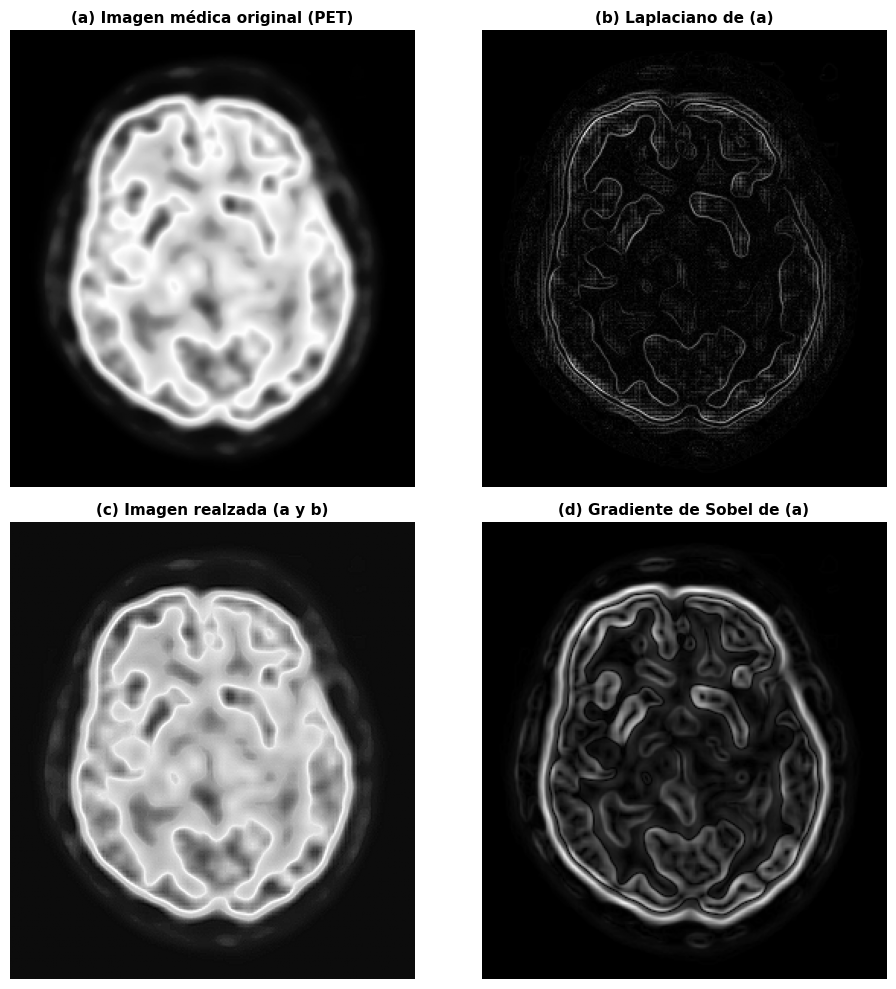

In [39]:
# --- Ejercicio 3:  ---

im = Image.open('data/pet_scan.jpg').convert('L')
im.thumbnail((300, 300))
f = np.array(im, dtype=float) / 255.0

# (a) Imagen original: f

# (b) Laplaciano 
H_lap = np.array([[ 0,  1,  0],
                  [ 1, -4,  1],
                  [ 0,  1,  0]])
lap = apply_filter(f, H_lap)

# (c) Imagen realzada obtenida al restar/sumar a y b
g = np.clip(f - lap, 0.0, 1.0)

# (d) Gradiente de Sobel
H_sx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
H_sy = np.array([[-1, -2, -1], [ 0,  0,  0], [ 1,  2,  1]])
sx = apply_filter(f, H_sx)
sy = apply_filter(f, H_sy)
sobel_mag = np.sqrt(sx**2 + sy**2)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(f, cmap='gray')
axes[0, 0].set_title('(a) Imagen médica original (PET)', fontsize=11, fontweight='bold')

axes[0, 1].imshow(np.abs(lap), cmap='gray')
axes[0, 1].set_title('(b) Laplaciano de (a)', fontsize=11, fontweight='bold')

axes[1, 0].imshow(g, cmap='gray')
axes[1, 0].set_title('(c) Imagen realzada (a y b)', fontsize=11, fontweight='bold')

axes[1, 1].imshow(sobel_mag, cmap='gray')
axes[1, 1].set_title('(d) Gradiente de Sobel de (a)', fontsize=11, fontweight='bold')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Conclusiones y Reflexión Final

A lo largo de esta actividad práctica pudimos explorar cómo funcionan los filtros espaciales y las convoluciones, pasando desde la implementación manual en Python hasta el uso de PyTorch y su aplicación en imágenes médicas reales.

1. **Convolución básica desde cero (`apply_filter`):**
   Programar la función de convolución fue muy útil para entender exactamente qué ocurre píxel por píxel. Aunque este método en Python es más lento que usar librerías optimizadas, deja muy clara la mecánica del kernel y por qué el padding es indispensable para no recortar ni perder los bordes de la imagen.

2. **Detectores de bordes (Prewitt, Sobel y Laplaciano):**
   Un hallazgo importante fue comprender por qué Prewitt y Sobel requieren dos kernels ($G_x$ y $G_y$): al ser derivadas de primer orden (gradientes), miden cambios en una dirección específica y se vuelve obligatorio calcular la magnitud vectorial para capturar bordes tanto horizontales como verticales o diagonales. Por su parte, el Laplaciano resultó ser el más eficiente computacionalmente porque detecta bordes en todas las direcciones con una sola convolución, aunque Sobel genera contornos con menor ruido.

3. **Convolución con PyTorch:**
   En esta sección vimos el salto hacia herramientas que se usan en proyectos reales y Deep Learning. El aprendizaje más importante fue entender el formato de PyTorch `(Batch, Canales, Alto, Ancho)`, además de comprobar lo rápido y directo que resulta aplicar filtros predefinidos mediante tensores.

4. **Realce por factor Alfa:**
   Al experimentar con el factor de realce comprobamos que restar la máscara de líneas multiplicada por $\alpha > 1$ efectivamente incrementa la nitidez aparente de la imagen. Sin embargo, el hallazgo práctico es que existe un límite: con un valor moderado (como $\alpha = 1.8$) los bordes ganan definición, pero si se exagera el valor (como $\alpha = 3.0$), se empiezan a saturar los contrastes y se amplifica el ruido.

5. **Aplicación Médica (PET):**
   Aplicar estos conceptos sobre una tomografía PET real demostró la utilidad práctica de la materia. Las imágenes médicas suelen ser ruidosas y de bajo contraste debido a la física de captura de radiación. Pudimos observar que mientras el Laplaciano ayuda a resaltar las transiciones finas y los detalles internos, el gradiente de Sobel marca con fuerza la silueta anatómica general. Esto confirma que en situaciones reales rara vez basta con un solo filtro, sino que se requiere analizar qué aporta cada etapa de procesamiento.